**Graph Coloring via GNN**

*Alessandro Calderoni*

*Importing necessary libraries*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'cmr10'
mpl.rcParams['axes.formatter.use_mathtext'] = True
mpl.rcParams['mathtext.fontset'] = 'cm'
import matplotlib.ticker as mticker
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, LogLocator)

import requests
import os
import time
import random

import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

!pip install torchsummary
from torchsummary import summary

!pip install torch_geometric
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv



**Example Graphs**

*   The graph is in DIMACS format, it can be read and then saved using the *networkx* library
*   We verify the number of nodes and edges
*   The library allows, together with *matplotlib*, to visualize it

In [ ]:
def parse_dimacs_col_from_text(lines):
    G = nx.Graph()

    for line in lines:
        line = line.strip()
        # Salta le righe vuote o i commenti
        if not line or line.startswith('c'):
            continue

        parts = line.split()

        # Sottostringa di configurazione del problema: p edge NODI ARCHI
        if parts[0] == 'p':
            num_nodes = int(parts[2])
            G.add_nodes_from(range(1, num_nodes + 1))

        # Sottostringa dell'arco: e NODO_1 NODO_2
        elif parts[0] == 'e':
            u = int(parts[1])
            v = int(parts[2])
            G.add_edge(u, v)

    return G

url_raw4  = 'https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g4.col'
url_raw18 = 'https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g18.col'

response4  = requests.get(url_raw4)
response18 = requests.get(url_raw18)

G4 = parse_dimacs_col_from_text(response4.text.splitlines())

print(f"Grafo caricato con successo!")
print(f"Nodi: {G4.number_of_nodes()}")
print(f"Archi: {G4.number_of_edges()}")

G18 = parse_dimacs_col_from_text(response18.text.splitlines())

print(f"Grafo caricato con successo!")
print(f"Nodi: {G18.number_of_nodes()}")
print(f"Archi: {G18.number_of_edges()}")


######################################################
######### SCEGLIERE IL GRAFO DA COLORARE !!! #########
######################################################

G = G18.copy() # G18.copy()

######################################################
######################################################
######################################################


Grafo caricato con successo!
Nodi: 23
Archi: 71
Grafo caricato con successo!
Nodi: 128
Archi: 1170


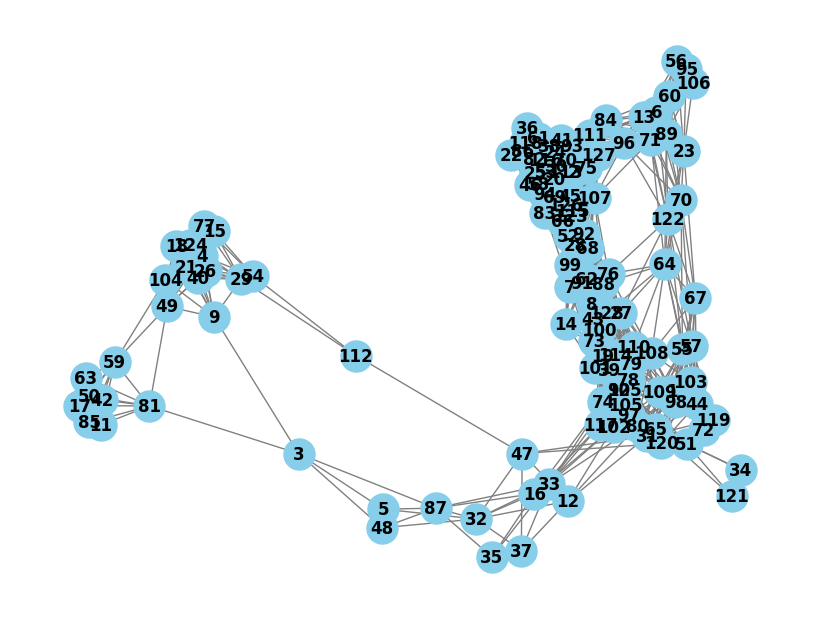

In [ ]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_weight='bold')
plt.show()

**Greedy Algorithm**

--- BASELINE GREEDY (NetworkX) ---
Numero Cromatico Greedy: 20, tempo impiegato: 0.0007762908935546875 s


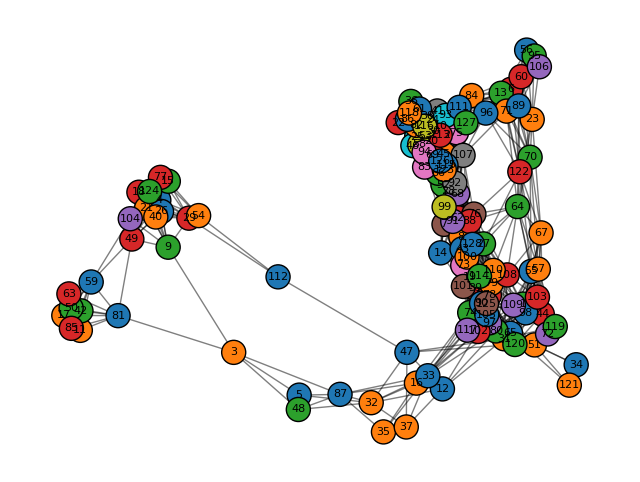

In [ ]:
def compute_greedy_baseline(G_nx):

    start_time = time.time()
    greedy_coloring = nx.greedy_color(G_nx, strategy="largest_first")
    end_time = time.time()

    num_colors_greedy = max(greedy_coloring.values()) + 1

    print(f"--- BASELINE GREEDY (NetworkX) ---")
    print(f"Numero Cromatico Greedy: {num_colors_greedy}, tempo impiegato: {end_time - start_time} s")

    return greedy_coloring, num_colors_greedy


colorazione_greedy, c_greedy = compute_greedy_baseline(G)

def plot_greedy_result(G_nx, greedy_coloring):

    node_colors_list = [greedy_coloring[node] for node in sorted(G_nx.nodes())]

    cmap = plt.get_cmap('tab10', max(node_colors_list) + 1)
    color_map = [cmap(color) for color in node_colors_list]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G_nx, pos, node_color=color_map, node_size=300, edgecolors='black')
    nx.draw_networkx_edges(G_nx, pos, edge_color='black', alpha=0.5)
    nx.draw_networkx_labels(G_nx, pos, font_size=8)

    plt.axis('off')
    plt.show()

plot_greedy_result(G, colorazione_greedy)

**GNN Framework Start**


**Embedding**:
The first thing to do is to assign an initial embedding to the nodes of the graph:
- A possible choice is to assign a one-hot vector to each node indicating its degree, but this leads to convergence problems;
- A better choice corresponds to a one-hot vector that simply indicates the node index;
- Another possible choice is a random vector in [0,1]^c, where c is the number of available colors.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using',device, 'device')

G = nx.convert_node_labels_to_integers(G, first_label=0, ordering="default")
num_nodes = G.number_of_nodes()

dim_embedding = num_nodes
x_init = torch.eye(num_nodes, dtype=torch.float)

G_directed = G.to_directed()

edges = list(G_directed.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

graph_data = Data(x=x_init, edge_index=edge_index)

graph_data = graph_data.to(device)

print(f"Grafo caricato con successo sulla device: {device}")
print(f"Numero di Nodi: {num_nodes}")
print(f"Dimensione dell'Embedding d_in: {dim_embedding}")
print(f"Formato Matrice Feature (X): {graph_data.x.shape}")
print(f"Formato Lista Archi (edge_index): {graph_data.edge_index.shape}")

Using cpu device
Grafo caricato con successo sulla device: cpu
Numero di Nodi: 128
Dimensione dell'Embedding d_in: 128
Formato Matrice Feature (X): torch.Size([128, 128])
Formato Lista Archi (edge_index): torch.Size([2, 2340])


**Graph Neural Network Model**

Let's implement a simple GNN based on `SAGEConv`.

In [ ]:

class PottsColoringNet(nn.Module):
    def __init__(self, in_channels, num_colors):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, 64)
        self.conv2 = SAGEConv(64, 64)

        self.fc_out = nn.Linear(64, num_colors)

        self.activation = F.relu

    def forward(self, x, edge_index):

        x = self.activation(self.conv1(x, edge_index))
        x = self.activation(self.conv2(x, edge_index))

        x = self.fc_out(x)

        return F.softmax(x, dim=-1)

**Loss, Entropy and Conflict Metric**

In [ ]:
# ======================
# 1. POTTS ENERGY LOSS
# ======================
def potts_energy_loss(p, edge_index):
    idx_i = edge_index[0]
    idx_j = edge_index[1]

    edge_overlaps = torch.sum(p[idx_i] * p[idx_j], dim=-1)
    total_energy = 0.5 * torch.sum(edge_overlaps)     # Stiamo dividendo per 2 perchè il grafo è directed.
    num_real_edges = edge_index.size(1) // 2

    return total_energy / (num_real_edges)


# ==================
# 2. ENTROPY LOSS
# ==================

def entropy(p, eps=1e-8):
    entropy_per_node = -torch.sum(p * torch.log(p + eps), dim=-1)

    return torch.mean(entropy_per_node)

# =============================================
# 3. VALUTAZIONE METRICHE (CONFLITTI DISCRETI)
# =============================================
def compute_discretized_conflicts(p, edge_index):

    colors = torch.argmax(p, dim=-1)

    idx_i = edge_index[0]
    idx_j = edge_index[1]

    conflicting_edges = (colors[idx_i] == colors[idx_j])
    n_conflicts = int(0.5 * torch.sum(conflicting_edges).item())
    num_real_edges = edge_index.size(1) // 2
    error_norm = n_conflicts / num_real_edges

    return n_conflicts, error_norm

**Training Function**
- The training function takes as input the number of available colors $c$, the graph and its properties, and the training hyperparameters.
- It returns the colored graph, the number of conflicts, the number of colors used, and the training metric measurements.

In [ ]:
def train_coloring_model(
    c,
    graph_data,
    dim_embedding,
    device,
    num_epochs=1000,
    patience=250,
    learning_rate=0.003,
    lambda_entropy_=0.005,
    tau_0=200,
    verbose=False
):
    model = PottsColoringNet(dim_embedding, c).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_conflicts = float("inf")
    best_colors_used = c
    best_coloring = None

    epochs_since_best = 0
    train_loss_curve = []
    potts_curve = []
    entropy_curve = []
    conflicts_curve = []
    error_curve = []

    print("\n" + "=" * 60)
    print(f"Inizio ottimizzazione per c={c} colori...")
    print("=" * 60)

    start_time = time.time()

    for epoch in range(num_epochs):
        lambda_entropy = lambda_entropy_ * epoch / tau_0

        model.train()
        optimizer.zero_grad()

        output = model(graph_data.x, graph_data.edge_index)
        energy_term = potts_energy_loss(output, graph_data.edge_index)
        entropy_term = entropy(output)

        loss = energy_term + lambda_entropy * entropy_term
        loss.backward()
        optimizer.step()

        train_loss_curve.append(loss.item())
        potts_curve.append(energy_term.item())
        entropy_curve.append(entropy_term.item())

        # EVALUTAION E SALVATAGGI IN MEMORIA
        model.eval()
        with torch.no_grad():
            eval_output = model(graph_data.x, graph_data.edge_index)
            n_conflicts, norm_error = compute_discretized_conflicts(eval_output, graph_data.edge_index)
            conflicts_curve.append(n_conflicts)
            error_curve.append(norm_error)

        if n_conflicts < best_conflicts:
            best_conflicts = n_conflicts
            epochs_since_best = 0
            discrete_colors = torch.argmax(eval_output, dim=-1)
            best_colors_used = torch.unique(discrete_colors).numel()
            best_coloring = discrete_colors.cpu().numpy()
        else:
            epochs_since_best += 1

        if (epoch+1) % 50 == 0 and verbose:
            current_elapsed_time = time.time() - start_time
            discrete_colors = torch.argmax(eval_output, dim=-1)
            colori_usati = torch.unique(discrete_colors).numel()
            print(
                f"Epoca {epoch+1:03d}/{num_epochs} | Loss: {loss:.5f} | Potts: {energy_term:.5f} | Entropy: {entropy_term:.5f} | Conflitti: {n_conflicts} (Best: {best_conflicts}) | Colori Usati: {colori_usati}/{c} | Tempo: {current_elapsed_time:.2f}s"
            )

        # BREAK ANTICIPATI
        if n_conflicts == 0:
            print(f"\n🎉 Conflitti a zero all'epoca {epoch+1}. Terminazione anticipata.")
            break

        if epochs_since_best >= patience:
            print(f"\nEarly stopping attivato. Nessun miglioramento nei conflitti per {patience} epoche.")
            break

    elapsed_time = time.time() - start_time
    print(f"Miglior risultato: {best_conflicts} conflitti con {best_colors_used} colori. Tempo di training = {elapsed_time:.4f} s")

    history = {"loss_curve": train_loss_curve, "potts_curve": potts_curve ,"entropy_curve": entropy_curve ,"conflicts_curve": conflicts_curve, "error_curve": error_curve}

    return best_coloring, best_conflicts, history, best_colors_used

**Greedy Post-Processing Algorithm**
- It takes as input the coloring predicted by the network and returns a processed coloring through a greedy algorithm:
Iterating up to a maximum number `max_iters`, a conflicting node is randomly chosen. The new color to assign is randomly chosen from those that minimize conflicts.

In [ ]:
def count_conflicts(G, colors):
    return sum(1 for u, v in G.edges() if colors[u] == colors[v])

def min_conflicts_post_processing(G, initial_colors, num_colors, max_iters=2000):

    colors = initial_colors.copy()

    def get_conflicting_nodes():
        conflicting = set()
        for u, v in G.edges():
            if colors[u] == colors[v]:
                conflicting.add(u)
                conflicting.add(v)
        return list(conflicting)

    print("\t[Post-Processing] Avvio ricerca locale (Min-Conflicts)...")

    for i in range(max_iters):
        bad_nodes = get_conflicting_nodes()

        if not bad_nodes:
            print(f"\t[Post-Processing] SUCCESSO! 0 conflitti raggiunti in {i} iterazioni.")
            return colors, 0, len(np.unique(colors))

        node = random.choice(bad_nodes)
        neighbor_colors = [colors[neighbor] for neighbor in G.neighbors(node)]
        color_scores = {col: 0 for col in range(num_colors)}

        for nc in neighbor_colors:
            if nc < num_colors:
                color_scores[nc] += 1

        min_score = min(color_scores.values())
        best_colors = [col for col, score in color_scores.items() if score == min_score]

        colors[node] = random.choice(best_colors)

    final_conflicts = len(get_conflicting_nodes()) // 2
    best_colors_used = len(np.unique(colors))
    print(f"    [Post-Processing] Terminato limite iterazioni ({max_iters}). Conflitti rimasti: {final_conflicts}")
    return colors, final_conflicts, best_colors_used

**TEST**

Let's test the framework: we choose a number of colors $c$ and train the network; if the number of conflicts is below 10, we perform greedy post-processing.
Currently, multi-start is not yet implemented, so re-run the cell in case of poor convergence.

In [ ]:
### CONSIGLIAMO DI SCEGLIERE UN NUMERO VICINO ALLA TRANSIZIONE, c=5 per G4 e c=20 per G18 ###

c = 20


predicted_colors, min_conflicts, history, best_colors_used = train_coloring_model(
            c=c,
            graph_data=graph_data,
            dim_embedding=dim_embedding,
            device=device, verbose=True,
        )

if 1 <= min_conflicts <= 10:
    final_colors, final_conflicts, final_colors_used = min_conflicts_post_processing(
        G=G, initial_colors=predicted_colors, num_colors=c, max_iters=1000
    )
    min_conflicts = final_conflicts
    best_colors_used = final_colors_used
    node_color_indices = final_colors
else:
    node_color_indices = predicted_colors


Inizio ottimizzazione per c=20 colori...
Epoca 050/1000 | Loss: 0.05367 | Potts: 0.05000 | Entropy: 2.99571 | Conflitti: 129 (Best: 89) | Colori Usati: 16/20 | Tempo: 0.47s
Epoca 100/1000 | Loss: 0.05741 | Potts: 0.05000 | Entropy: 2.99565 | Conflitti: 98 (Best: 71) | Colori Usati: 15/20 | Tempo: 0.79s
Epoca 150/1000 | Loss: 0.05261 | Potts: 0.04317 | Entropy: 2.53393 | Conflitti: 157 (Best: 71) | Colori Usati: 15/20 | Tempo: 1.10s
Epoca 200/1000 | Loss: 0.02921 | Potts: 0.02260 | Entropy: 1.32788 | Conflitti: 48 (Best: 43) | Colori Usati: 15/20 | Tempo: 1.41s
Epoca 250/1000 | Loss: 0.01800 | Potts: 0.01357 | Entropy: 0.71172 | Conflitti: 24 (Best: 16) | Colori Usati: 13/20 | Tempo: 1.75s
Epoca 300/1000 | Loss: 0.01146 | Potts: 0.00854 | Entropy: 0.39051 | Conflitti: 7 (Best: 5) | Colori Usati: 19/20 | Tempo: 2.09s
Epoca 350/1000 | Loss: 0.00687 | Potts: 0.00550 | Entropy: 0.15662 | Conflitti: 5 (Best: 5) | Colori Usati: 19/20 | Tempo: 2.41s
Epoca 400/1000 | Loss: 0.00439 | Potts: 0.0

Loss, Conflicts vs epoch

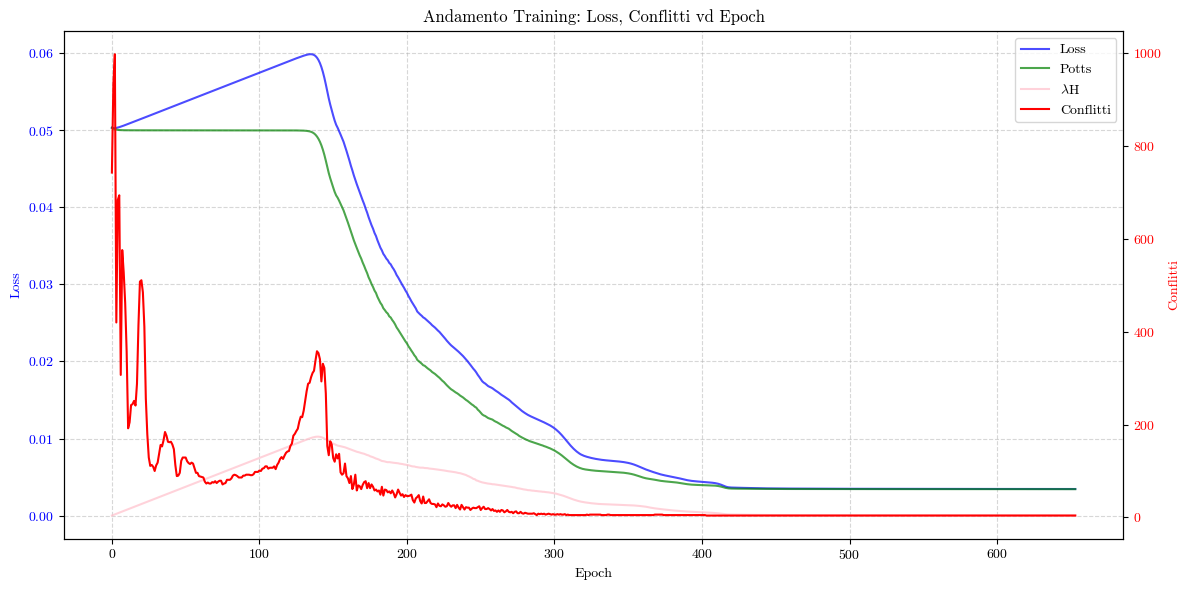

In [ ]:
# Visualizzazione di Loss, Conflitti ed Errore Normalizzato
fig, ax1 = plt.subplots(figsize=(12, 6))

# Asse per la Loss
ax1.plot(history["loss_curve"], color='blue', label='Loss', alpha=0.7)
ax1.plot(history["potts_curve"], color='green', label='Potts', alpha=0.7)
ax1.plot([i-j for i,j in zip(history["loss_curve"],history["potts_curve"])], color='pink', label='$\\lambda$H', alpha=0.7)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.5)

# Secondo asse per Conflitti ed Errore
ax2 = ax1.twinx()
ax2.plot(history["conflicts_curve"], color='red', label='Conflitti', linewidth=1.5)
ax2.set_ylabel("Conflitti", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Andamento Training: Loss, Conflitti vd Epoch")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")

plt.tight_layout()
plt.show()

**Obtained Coloring**
- Visualization of the best coloring found (GNN + eventual Post-Processing)

--- RISULTATO VISUALIZZAZIONE ---
Colori usati: 20
Conflitti: 0


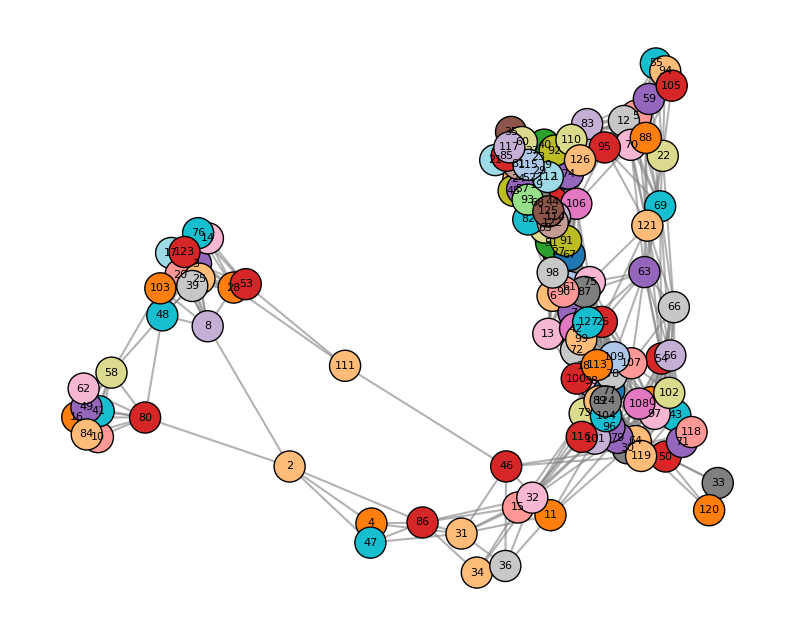

In [ ]:
edge_colors = []
for u, v in G.edges():
    if node_color_indices[u] == node_color_indices[v]:
        edge_colors.append('red')
    else:
        edge_colors.append('gray')

print(f"--- RISULTATO VISUALIZZAZIONE ---")
print(f"Colori usati: {best_colors_used}")
print(f"Conflitti: {min_conflicts}")

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

cmap = plt.get_cmap('tab20', max(best_colors_used, 1))

unique_colors = np.unique(node_color_indices)
node_colors = [cmap(np.where(unique_colors == c_idx)[0][0]) for c_idx in node_color_indices]

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors='black')
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.6, width=1.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

plt.axis("off")
plt.show()

**Optimized Chromatic Number Estimation**

- Starting from $c = \mathrm{maxdegree}{(G)} + 1$, it attempts to color the graph. If successful, it decreases the number of available colors. This provides an upper bound for the chromatic number.
- For each color, we repeat the operation `num_runs = 4` times (multi-start) using threshold post-processing in case of `#conflicts` < `soglia_pp`.

In [ ]:
grado_massimo = max(dict(G.degree()).values())
c_start = grado_massimo + 1

c_min_assoluto = 2
num_runs = 4
soglia_pp = 10

best_final_colors = None
estimated_chromatic_number = None

print("\n" + "=" * 60)
print("INIZIO RICERCA DEL NUMERO CROMATICO (DALL'ALTO AL BASSO)")
print("=" * 60)

c = c_start

while c >= c_min_assoluto:
    print(f"\n>>> Testando budget di colori (c) = {c} <<<")
    colorazione_trovata_per_questo_c = False

    for run in range(1, num_runs + 1):
        print(f"  --- Run {run}/{num_runs} ---")

        predicted_colors, min_conflicts, history, gnn_colors_used = train_coloring_model(
            c=c, graph_data=graph_data, dim_embedding=dim_embedding, device=device
        )

        initial_conflict_count = min_conflicts

        final_colors = predicted_colors
        final_conflict_count = initial_conflict_count
        final_colors_used = gnn_colors_used

        if 0 < initial_conflict_count <= soglia_pp:
            final_colors, final_conflict_count, final_colors_used = min_conflicts_post_processing(
                G=G, initial_colors=predicted_colors, num_colors=c, max_iters=500
            )

        if final_conflict_count == 0:
            best_final_colors = final_colors
            estimated_chromatic_number = final_colors_used
            colorazione_trovata_per_questo_c = True
            c = final_colors_used - 1
            break

    if not colorazione_trovata_per_questo_c:
        print(f"\n[X] NESSUNA soluzione trovata con budget {c}. Fine ricerca.")
        break

print("\n" + "=" * 60)
print("RIEPILOGO FINALE")
print("=" * 60)
if estimated_chromatic_number is not None:
    print(f"Il Numero Cromatico stimato per il grafo è: {estimated_chromatic_number}")
else:
    print("Non è stata trovata una colorazione valida durante la ricerca.")


INIZIO RICERCA DEL NUMERO CROMATICO (DALL'ALTO AL BASSO)

>>> Testando budget di colori (c) = 39 <<<
  --- Run 1/4 ---

Inizio ottimizzazione per c=39 colori...

Early stopping attivato. Nessun miglioramento nei conflitti per 250 epoche.
Miglior risultato: 6 conflitti con 20 colori. Tempo di training = 5.4197 s
	[Post-Processing] Avvio ricerca locale (Min-Conflicts)...
	[Post-Processing] SUCCESSO! 0 conflitti raggiunti in 6 iterazioni.

>>> Testando budget di colori (c) = 25 <<<
  --- Run 1/4 ---

Inizio ottimizzazione per c=25 colori...

Early stopping attivato. Nessun miglioramento nei conflitti per 250 epoche.
Miglior risultato: 2 conflitti con 22 colori. Tempo di training = 5.6205 s
	[Post-Processing] Avvio ricerca locale (Min-Conflicts)...
	[Post-Processing] SUCCESSO! 0 conflitti raggiunti in 2 iterazioni.

>>> Testando budget di colori (c) = 23 <<<
  --- Run 1/4 ---

Inizio ottimizzazione per c=23 colori...

Early stopping attivato. Nessun miglioramento nei conflitti per 250 epo

## Appendix
### Conflicts vs Colors Plot Production
- The code below produces a graph showing the trend of conflicts as a function of the number of colors used around the phase transition (chromatic number).
- It takes ~10 min to execute, as it estimates variance and mean over numerous runs, for each choice of $c$.

In [ ]:
grado_massimo = max(dict(G.degree()).values())
c_start = estimated_chromatic_number + 2
c_min_plot = estimated_chromatic_number - 5

num_runs_per_c = 20
soglia_pp = 10

colors_tested = []
mean_conflicts = []
std_conflicts = []

print("\n" + "=" * 60)
print("INIZIO ANALISI CONFLITTI VS NUMERO DI COLORI")
print("Questo processo richiederà del tempo a causa del numero elevato di run per colore.")
print("=\n" + "=" * 60)

# Iterate from c_start down to c_min_plot
for c_val in range(c_start, c_min_plot - 1, -1):
    print(f"\n>>> Testando budget di colori (c) = {c_val} (Runs: {num_runs_per_c}) <<<")
    conflicts_for_c = []

    for run_idx in range(1, num_runs_per_c + 1):
        print(f"  --- c={c_val}, Run {run_idx}/{num_runs_per_c} ---")

        # Call train_coloring_model with appropriate parameters
        # Use verbose=False to keep the output clean during the loop
        predicted_colors, min_conflicts, history_dummy, gnn_colors_used = train_coloring_model(
            c=c_val,
            graph_data=graph_data,
            dim_embedding=dim_embedding,
            device=device,
            verbose=False, # Suppress verbose output for multiple runs
            num_epochs=1000,
            patience=250,
            lambda_entropy_=0.005
        )

        final_conflict_count = min_conflicts

        # Apply post-processing if initial conflicts are within the threshold
        if 0 < final_conflict_count <= soglia_pp:
            _, final_conflict_count_pp, _ = min_conflicts_post_processing(
                G=G, initial_colors=predicted_colors, num_colors=c_val, max_iters=500
            )
            final_conflict_count = final_conflict_count_pp # Update conflict count after PP

        conflicts_for_c.append(final_conflict_count)

    if conflicts_for_c: # Ensure conflicts_for_c is not empty before calculating
        colors_tested.append(c_val)
        mean_conflicts.append(np.mean(conflicts_for_c))
        std_conflicts.append(np.std(conflicts_for_c))
        print(f"  Media conflitti per c={c_val}: {np.mean(conflicts_for_c):.2f} +/- {np.std(conflicts_for_c):.2f}")
    else:
        print(f"  Nessun dato di conflitto raccolto per c={c_val}")


print("\n" + "=" * 60)
print("FINE ANALISI")
print("=" * 60)




INIZIO ANALISI CONFLITTI VS NUMERO DI COLORI
Questo processo richiederà del tempo a causa del numero elevato di run per colore.
=

>>> Testando budget di colori (c) = 22 (Runs: 20) <<<
  --- c=22, Run 1/20 ---

Inizio ottimizzazione per c=22 colori...

Early stopping attivato. Nessun miglioramento nei conflitti per 250 epoche.
Miglior risultato: 5 conflitti con 19 colori. Tempo di training = 4.5763 s
	[Post-Processing] Avvio ricerca locale (Min-Conflicts)...
	[Post-Processing] SUCCESSO! 0 conflitti raggiunti in 35 iterazioni.
  --- c=22, Run 2/20 ---

Inizio ottimizzazione per c=22 colori...

Early stopping attivato. Nessun miglioramento nei conflitti per 250 epoche.
Miglior risultato: 3 conflitti con 21 colori. Tempo di training = 4.5604 s
	[Post-Processing] Avvio ricerca locale (Min-Conflicts)...
	[Post-Processing] SUCCESSO! 0 conflitti raggiunti in 8 iterazioni.
  --- c=22, Run 3/20 ---

Inizio ottimizzazione per c=22 colori...

Early stopping attivato. Nessun miglioramento nei con

/tmp/ipykernel_3037/4113008448.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(colors_tested, mean_conflicts, yerr=std_conflicts, fmt='-o', capsize=5,


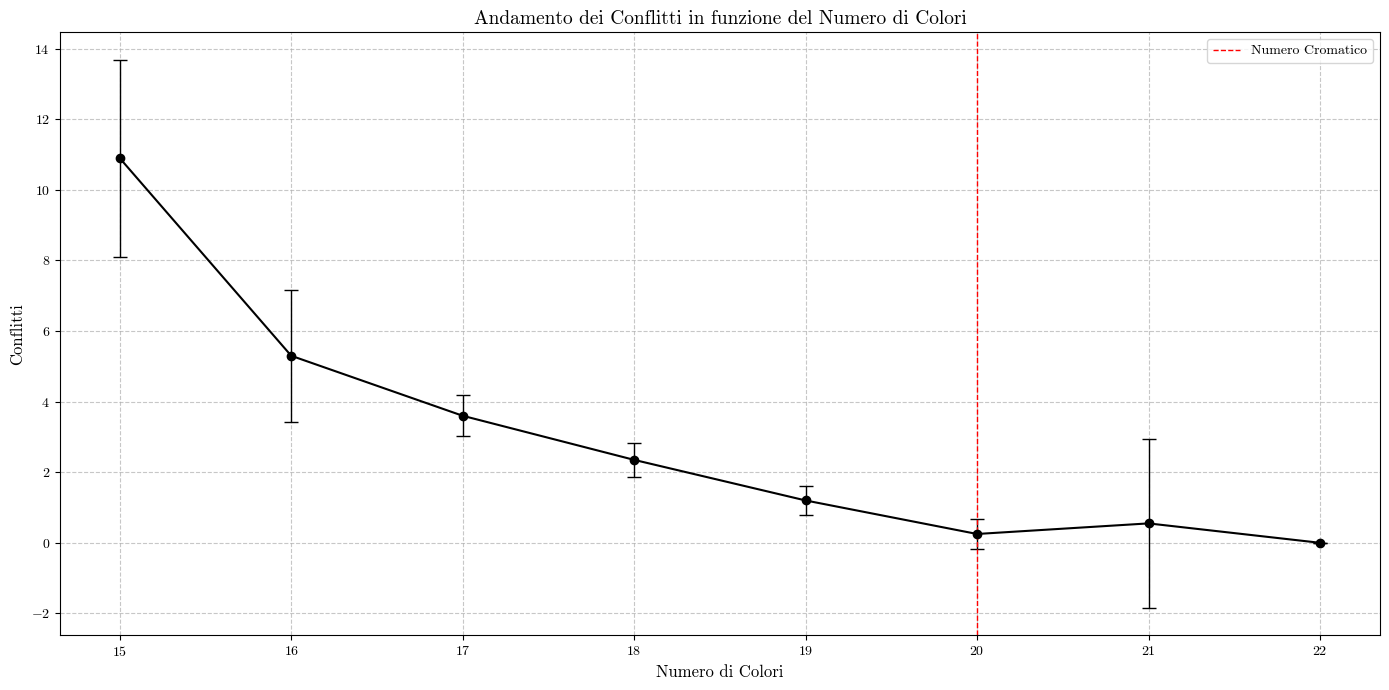

In [ ]:
# Plotting the results
fig, ax = plt.subplots(figsize=(14, 7)) # Adjust figure size for better readability

# Plot mean conflicts with error bars
ax.errorbar(colors_tested, mean_conflicts, yerr=std_conflicts, fmt='-o', capsize=5,
            color='black', elinewidth=1, marker='o', markersize=6,
            )

# Add a horizontal line at 0 conflicts for reference
ax.axvline(x=estimated_chromatic_number, color='red', linestyle='--', linewidth=1, label='Numero Cromatico')

ax.set_xlabel("Numero di Colori", fontsize=12)
ax.set_ylabel("Conflitti", fontsize=12)
ax.set_title("Andamento dei Conflitti in funzione del Numero di Colori", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

# Set x-axis ticks to show all tested c values, if feasible, otherwise use a subset
if len(colors_tested) < 20: # If few colors, show all
    ax.set_xticks(colors_tested)
else: # Otherwise, show a reasonable subset
    ax.xaxis.set_major_locator(MultipleLocator(2)) # Show every 2nd C value
    ax.xaxis.set_minor_locator(AutoMinorLocator())


ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("conflicts_vs_colors_analysis.pdf")
plt.show()